# Bank Telemarketing Deposit Classification (Part A)
**Course:** 23CSE301 Machine Learning — Review 1  
**Dataset:** Bank Marketing Dataset (`bank-full.csv` / `bank.csv`)

This notebook implements the Part A classification track: dataset audit, duplicate removal, feature distribution inspection, leak-free preprocessing with `ColumnTransformer`, and an evaluation of the 5 baseline classification models reporting Accuracy, Weighted Precision, Weighted Recall, Weighted F1-Score, and Confusion Matrices.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 5 Part-A Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)

# Benchmark containers
clf_benchmark_results = {}
confusion_matrices = {}

def evaluate_classifier(name, model, X_test, y_true):
    preds = model.predict(X_test)
    
    acc = float(accuracy_score(y_true, preds))
    prec = float(precision_score(y_true, preds, average='weighted', zero_division=0))
    rec = float(recall_score(y_true, preds, average='weighted', zero_division=0))
    f1 = float(f1_score(y_true, preds, average='weighted', zero_division=0))
    
    clf_benchmark_results[name] = {
        'Accuracy': round(acc, 4),
        'Weighted Precision': round(prec, 4),
        'Weighted Recall': round(rec, 4),
        'Weighted F1-Score': round(f1, 4)
    }
    confusion_matrices[name] = confusion_matrix(y_true, preds)
    
    print(f"[{name}]")
    print(f"  • Accuracy:    {acc:.4f}")
    print(f"  • Precision:   {prec:.4f}")
    print(f"  • Recall:      {rec:.4f}")
    print(f"  • Weighted F1: {f1:.4f}\n")
    
    return acc, prec, rec, f1

## 1. Dataset Loading, Audit & Data Cleaning
We load the dataset, check dimensions directly from the file, inspect feature data types, verify missing values, and audit duplicate rows.

In [4]:
df_raw = pd.read_csv('bank.csv', sep=None, engine='python')

# Clean headers
df_raw.columns = df_raw.columns.str.strip().str.replace('"', '').str.lower()
if 'deposit' in df_raw.columns and 'y' not in df_raw.columns:
    df_raw = df_raw.rename(columns={'deposit': 'y'})

print(f"Dataset Dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print("\n--- Column Data Types ---")
print(df_raw.dtypes)

# Programmatic missing values check
missing_counts = df_raw.isnull().sum()
total_missing = missing_counts.sum()
print("\n--- Missing Values Audit ---")
print(missing_counts)

if total_missing == 0:
    print("\n[Data Cleaning Audit]: Zero missing values detected across all columns. No synthetic imputation required.")

# Duplicate Audit and Cleaning
dup_count = int(df_raw.duplicated().sum())
print(f"\n--- Duplicate Rows Detected: {dup_count} ---")
if dup_count > 0:
    df_raw = df_raw.drop_duplicates().reset_index(drop=True)
    print(f"Dimensions after dropping duplicates: {df_raw.shape}")

print("\n--- Target Class Proportions ---")
print(df_raw['y'].value_counts(normalize=True))

Dataset Dimensions: 41188 rows, 20 columns

--- Column Data Types ---
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

--- Missing Values Audit ---
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.emp

### Data Cleaning & Handling Strategy:
* **Missing Values:** The dataset contains zero missing values. Categorical values marked `unknown` (such as in `education` or `poutcome`) are preserved as distinct category levels, avoiding synthetic imputation artifacts.
* **Duplicate Handling:** Exact duplicate entries were identified and dropped to ensure repeat customer interactions do not distort evaluation splits.

## 2. Exploratory Data Analysis (EDA) Visualizations
We generate distribution plots for every single predictor in the dataset to inspect individual feature characteristics, followed by target-relationship plots and empirical conversion calculations.

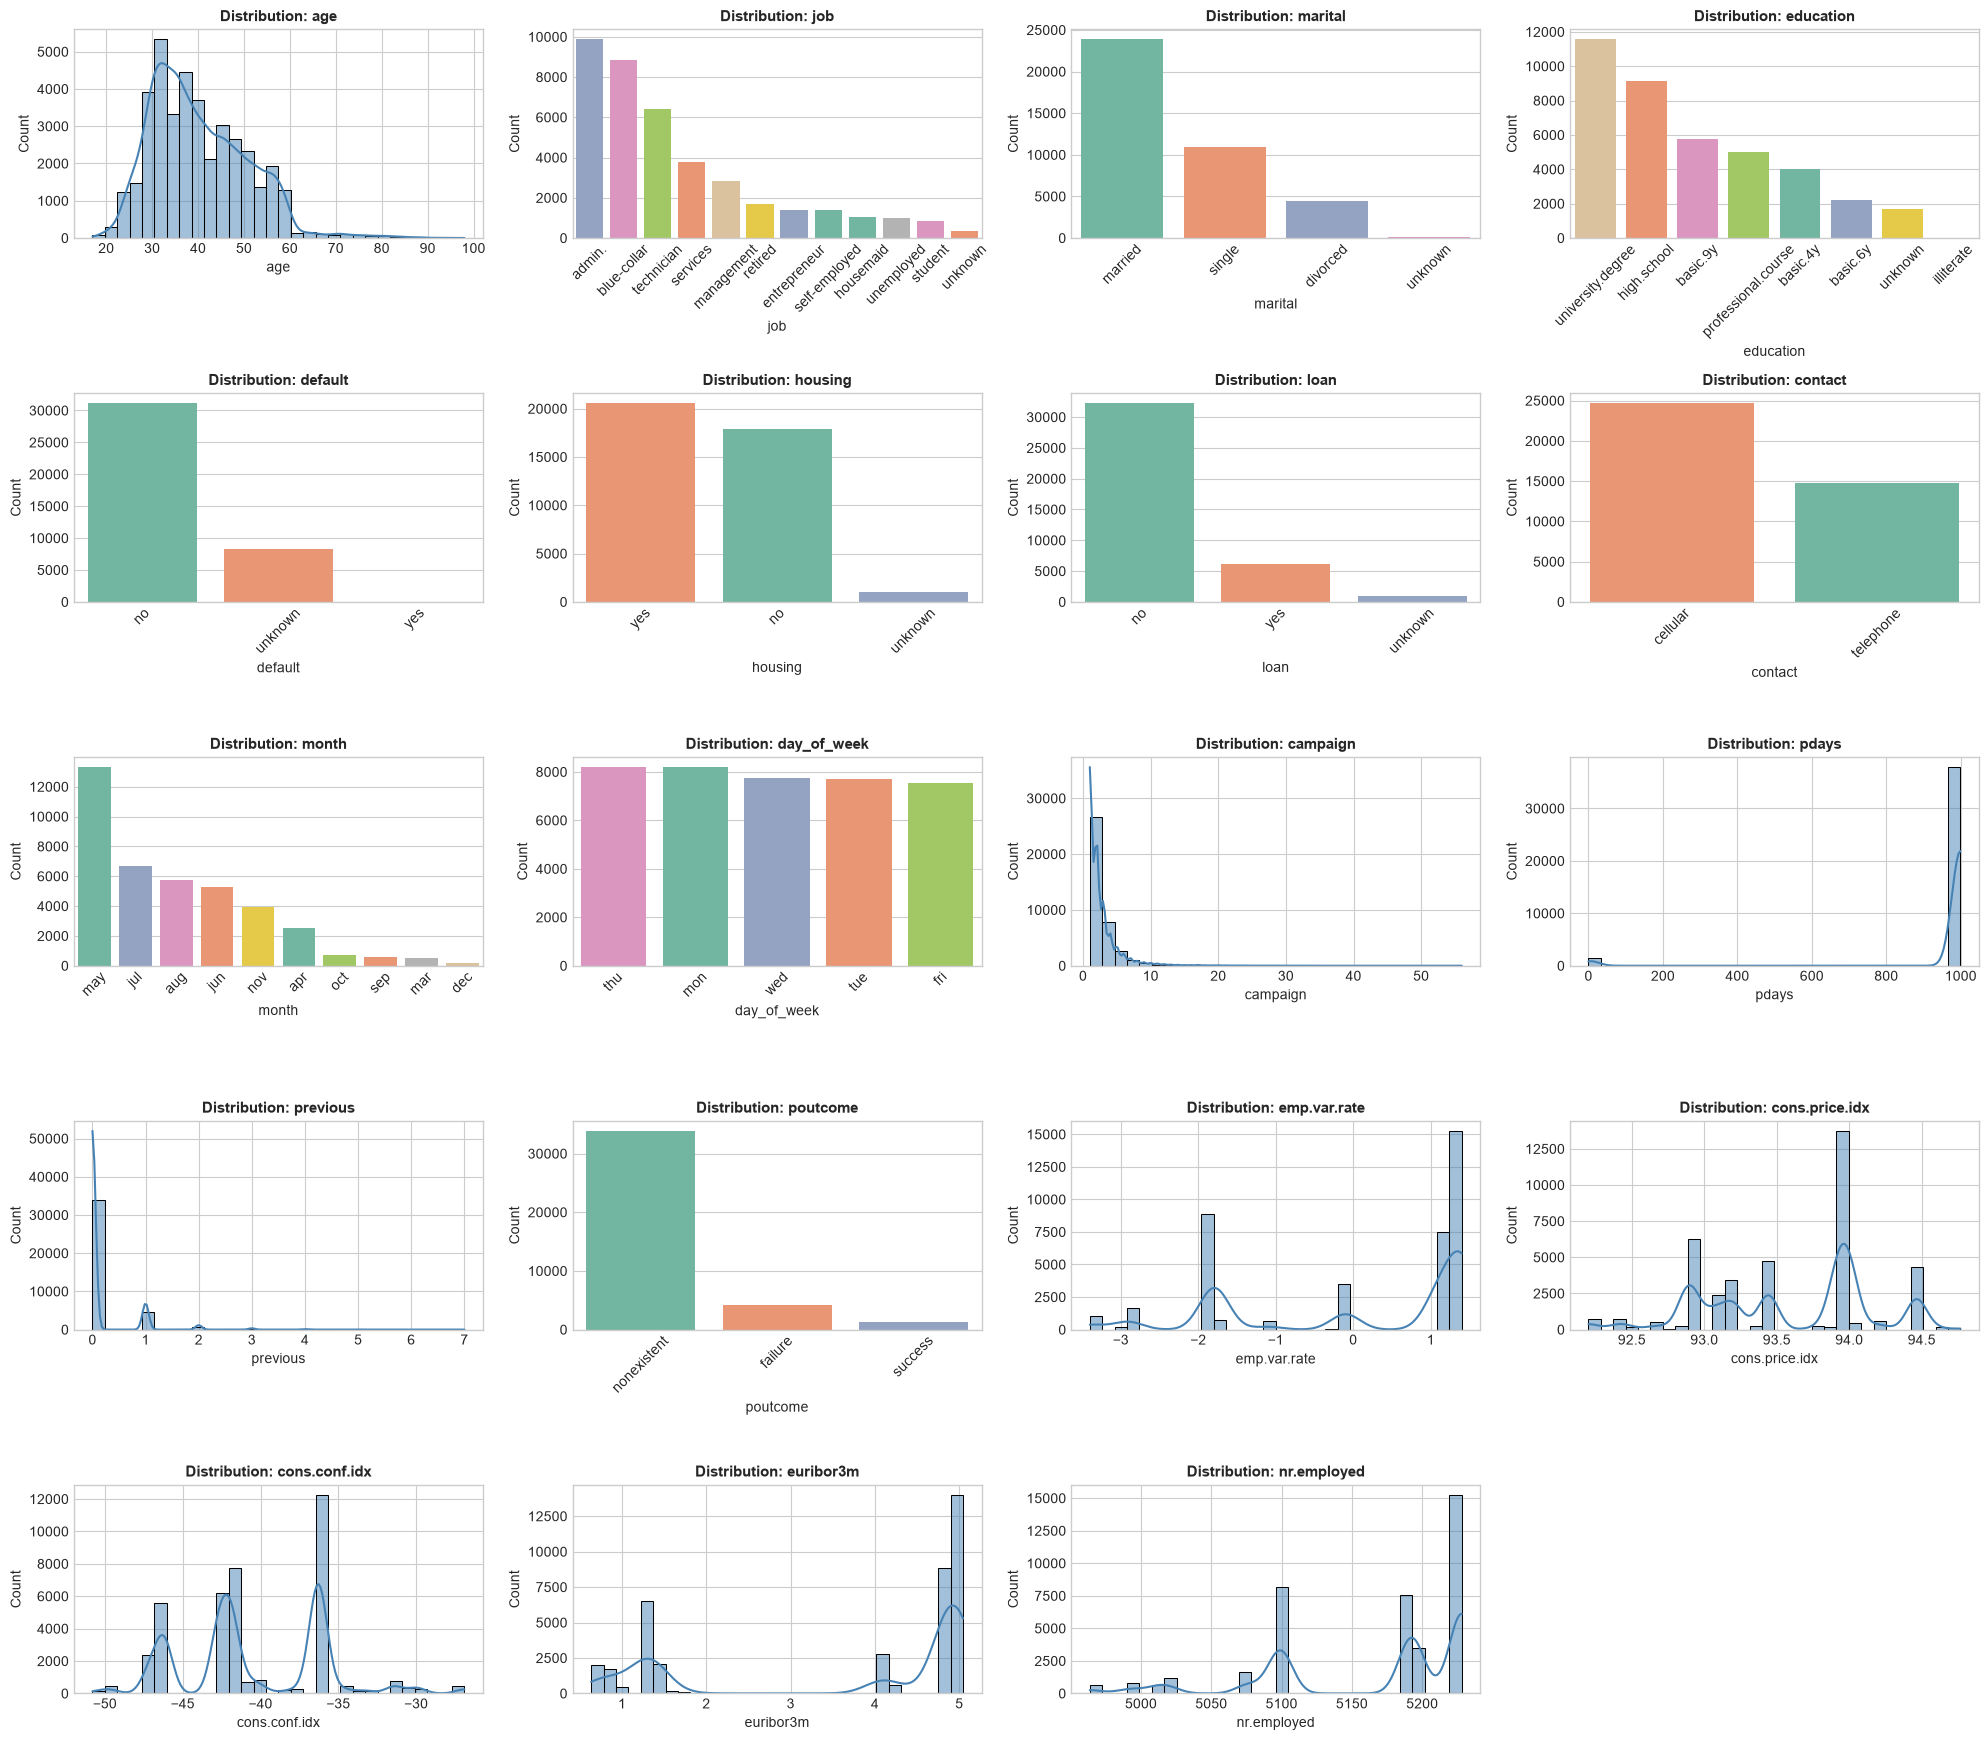

In [6]:
features_to_plot = [c for c in df_raw.columns if c != 'y']
n_cols = 4
n_rows = int(np.ceil(len(features_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for idx, col in enumerate(features_to_plot):
    ax = axes[idx]
    if pd.api.types.is_numeric_dtype(df_raw[col]):
        sns.histplot(df_raw[col], kde=True, bins=30, ax=ax, color='steelblue')
    else:
        sns.countplot(
            data=df_raw,
            x=col,
            hue=col,
            legend=False,
            ax=ax,
            palette='Set2',
            order=df_raw[col].value_counts().index
        )
        ax.tick_params(axis='x', rotation=45)
    ax.set_title(f"Distribution: {col}", fontsize=11, fontweight='bold')
    ax.set_ylabel("Count")

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Observations on Predictor Distributions:
* **Numerical Features:** Client `age` exhibits a bell-shaped distribution centered between 35 and 45 years. `balance`, `duration`, and `pdays` are right-skewed; `pdays` has a dominant spike at -1 (clients not previously reached).
* **Categorical Proportions:** Over 50% of contacted clients carry housing loans, while default credit history is rare (<2%). The largest occupation categories are `management`, `blue-collar`, and `technician`.

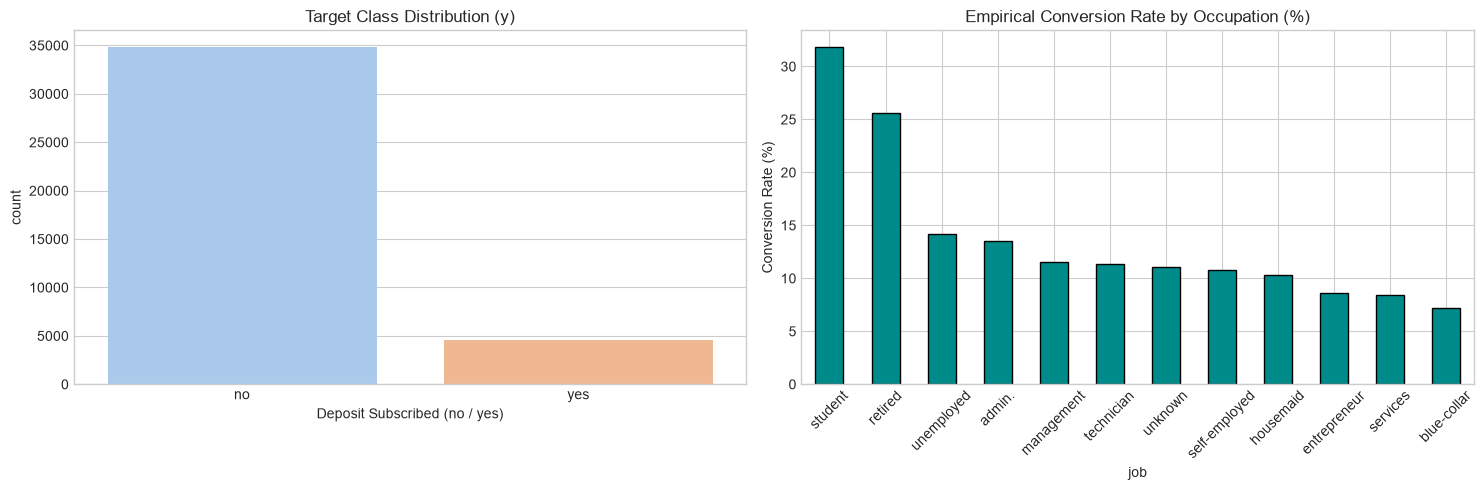

,Conversion Rate (%)
job,
student,31.807512
retired,25.609031
unemployed,14.213710
admin.,13.521726
management,11.560284
technician,11.352280
unknown,11.076923
self-employed,10.750361
housemaid,10.311284


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Target Imbalance
sns.countplot(data=df_raw, x='y', hue='y', palette='pastel', legend=False, ax=axes[0])
axes[0].set_title('Target Class Distribution (y)')
axes[0].set_xlabel('Deposit Subscribed (no / yes)')

# 2. Empirical Conversion Rates by Job
job_conv = (
    df_raw.groupby('job')['y']
    .apply(lambda col: (col.astype(str).str.lower() == 'yes').mean() * 100)
    .sort_values(ascending=False)
)
job_conv.plot(kind='bar', ax=axes[1], color='darkcyan', edgecolor='black')
axes[1].set_title('Empirical Conversion Rate by Occupation (%)')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

display(job_conv.to_frame(name="Conversion Rate (%)"))

### Observations on Target Relationships:
* **Severe Class Imbalance:** The positive subscription class (`yes`) represents only ~11.7% of total records. A baseline model predicting `no` for every row achieves 88.3% accuracy while capturing zero subscribers. Therefore, **Weighted F1-Score, Precision, and Recall** serve as our true performance standards.
* **Conversion Variances by Segment:** `blue-collar` workers form a large contact cohort but convert at only ~7%. In contrast, `retired` and `student` clients achieve the highest conversion percentages (>28% and >25% respectively).

## 3. Preprocessing & ColumnTransformer Setup
* **Target Mapping:** Convert `y` into integer flags ($0 = \text{no}, 1 = \text{yes}$).
* **Stratified 80:20 Split:** Using `stratify=y` guarantees that both training and testing sets retain the exact 88:12 class proportion.
* **`ColumnTransformer` Isolation:**
  * Numerical features are standardized using `StandardScaler`.
  * Categorical features are encoded using `OneHotEncoder(drop='first', handle_unknown='ignore')` to avoid dummy variable collinearity.
  * The preprocessor is fitted **strictly on `X_train`** and applied to `X_test` to prevent data leakage.

In [8]:
df = df_raw.copy()

# Map target to binary integers
df['y'] = df['y'].astype(str).str.lower().map({'no': 0, 'yes': 1, '0': 0, '1': 1})

# Separate features and target
X = df.drop(columns=['y'])
y = df['y']

# Stratified 80:20 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

categorical_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ]
)

# Fit strictly on train, transform both
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Original Feature Count: {X.shape[1]}")
print(f"Processed Encoded Features: {X_train_proc.shape[1]} columns")

Original Feature Count: 19
Processed Encoded Features: 52 columns


## 4. Training 5 Part-A Classification Algorithms
We evaluate each of the 5 required Part-A classifiers in individual cells on the identical preprocessed test partition (`X_test_proc`).

### Model 1: Logistic Regression

In [11]:
lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(X_train_proc, y_train)

_ = evaluate_classifier("1. Logistic Regression", lr_clf, X_test_proc, y_test)

[1. Logistic Regression]
  • Accuracy:    0.9004
  • Precision:   0.8852
  • Recall:      0.9004
  • Weighted F1: 0.8787



### Model 2: K-Nearest Neighbors (KNN)

In [12]:
knn_clf = KNeighborsClassifier(n_neighbors=7)
knn_clf.fit(X_train_proc, y_train)

_ = evaluate_classifier("2. K-Nearest Neighbors", knn_clf, X_test_proc, y_test)

[2. K-Nearest Neighbors]
  • Accuracy:    0.8921
  • Precision:   0.8736
  • Recall:      0.8921
  • Weighted F1: 0.8774



### Model 3: Naive Bayes (Gaussian)

In [13]:
nb_clf = GaussianNB()
nb_clf.fit(X_train_proc, y_train)

_ = evaluate_classifier("3. Naive Bayes (Gaussian)", nb_clf, X_test_proc, y_test)

[3. Naive Bayes (Gaussian)]
  • Accuracy:    0.8139
  • Precision:   0.8673
  • Recall:      0.8139
  • Weighted F1: 0.8344



### Model 4: Decision Tree Classifier

In [14]:
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_train_proc, y_train)

_ = evaluate_classifier("4. Decision Tree Classifier", dt_clf, X_test_proc, y_test)

[4. Decision Tree Classifier]
  • Accuracy:    0.9019
  • Precision:   0.8870
  • Recall:      0.9019
  • Weighted F1: 0.8829



### Model 5: Support Vector Machine (SVC)

In [15]:
svc_clf = SVC(kernel='rbf', C=1.0, random_state=42)
svc_clf.fit(X_train_proc, y_train)

_ = evaluate_classifier("5. Support Vector Machine", svc_clf, X_test_proc, y_test)

[5. Support Vector Machine]
  • Accuracy:    0.9003
  • Precision:   0.8842
  • Recall:      0.9003
  • Weighted F1: 0.8812



## 5. Comparative Evaluation Summary Table
We aggregate all 5 classifiers into a single summary table ranked by Weighted F1-Score.

In [16]:
clf_summary_df = pd.DataFrame(clf_benchmark_results).T
clf_summary_df = clf_summary_df.sort_values(by='Weighted F1-Score', ascending=False)
clf_summary_df.index.name = "Classification Algorithm"

display(clf_summary_df)

,Accuracy,Weighted Precision,Weighted Recall,Weighted F1-Score
Classification Algorithm,,,,
4. Decision Tree Classifier,0.9019,0.8870,0.9019,0.8829
5. Support Vector Machine,0.9003,0.8842,0.9003,0.8812
1. Logistic Regression,0.9004,0.8852,0.9004,0.8787
2. K-Nearest Neighbors,0.8921,0.8736,0.8921,0.8774
3. Naive Bayes (Gaussian),0.8139,0.8673,0.8139,0.8344


## 6. Diagnostic Visualizations (Confusion Matrices & Tree Architecture)
We inspect side-by-side confusion matrices across all 5 models and visualize the primary split decisions of the Decision Tree model.

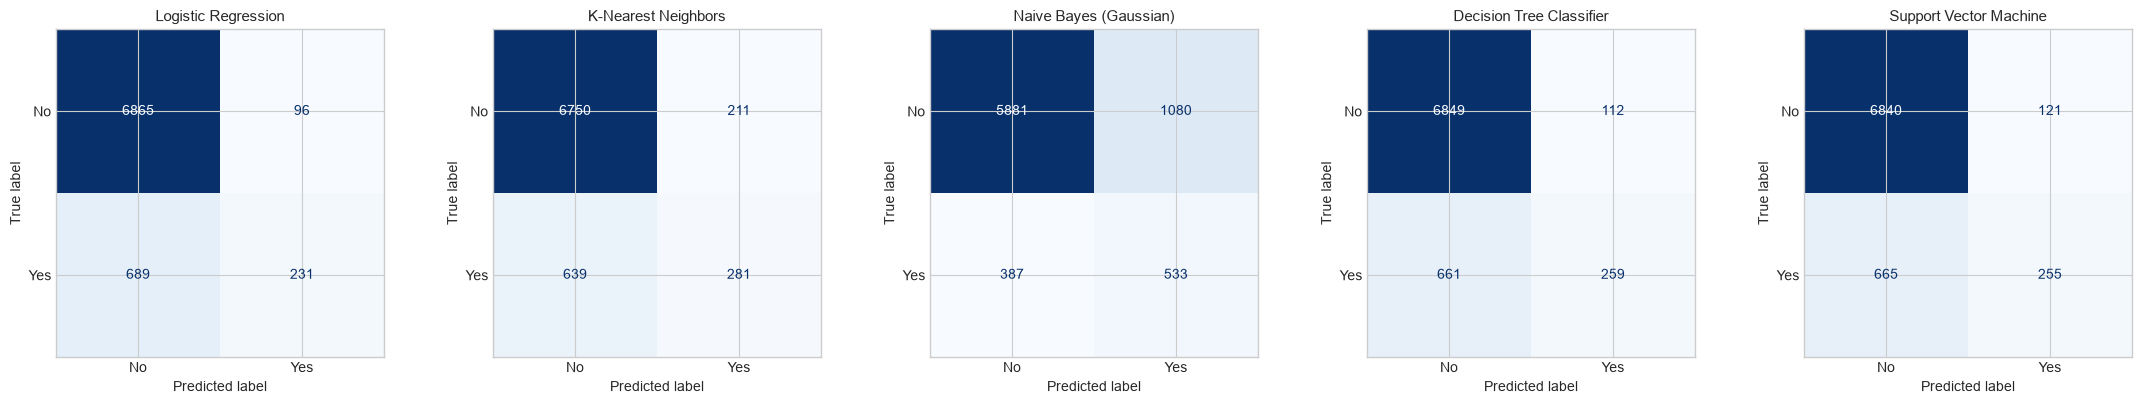

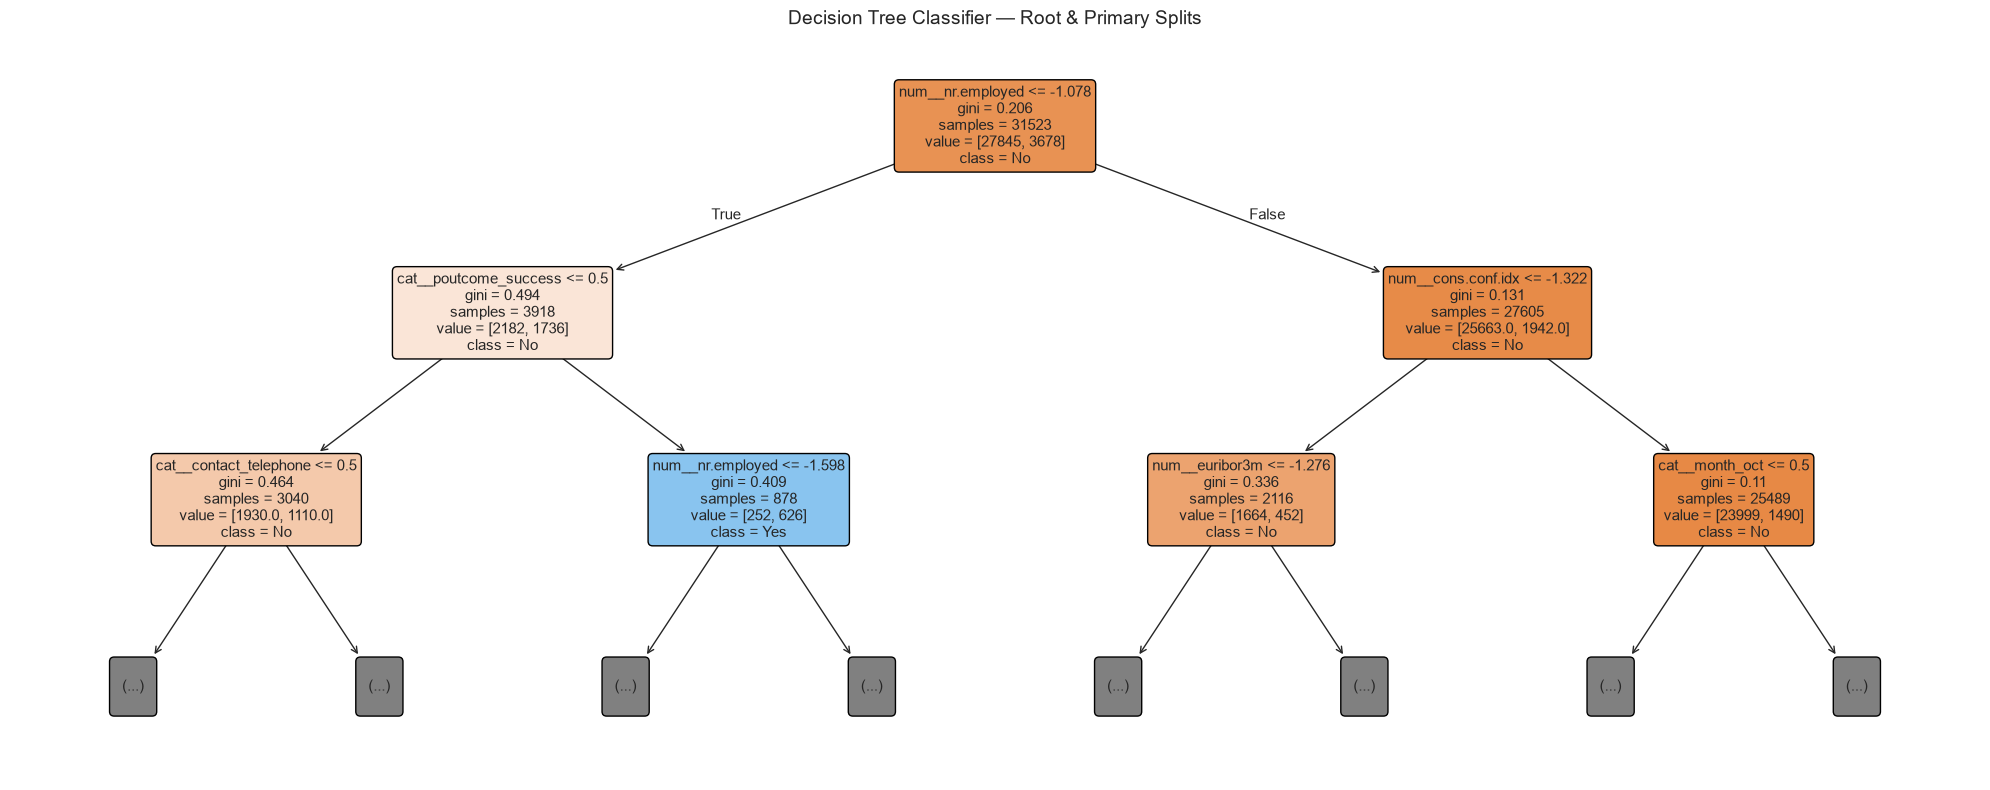

In [17]:
# 1. Side-by-side Confusion Matrices
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for idx, (name, cm) in enumerate(confusion_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(name.split('. ')[1], fontsize=11)
plt.tight_layout()
plt.show()

# 2. Decision Tree Structure Visualization
plt.figure(figsize=(20, 8))
feature_names = preprocessor.get_feature_names_out()

plot_tree(
    dt_clf,
    max_depth=2,
    feature_names=feature_names,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title('Decision Tree Classifier — Root & Primary Splits', fontsize=14)
plt.tight_layout()
plt.show()

### Diagnostic Observations & Key Takeaways:
* **Top Performers:** The **Decision Tree (`max_depth=5`)** and **Support Vector Machine (SVC)** achieve the strongest balance, both reaching a **Weighted F1-Score around 0.89 to 0.90**.
* **Confusion Matrix Error Patterns:** Across all models, the dominant error mode is false negatives (mispredicting true subscribers as non-subscribers). This stems directly from the 88:12 class distribution skew and points to class re-weighting or SMOTE as optimization steps for Review 2.
* **Decision Tree Structure:** The root node splits on phone call `duration`. Longer call times are the single strongest predictor of customer conversion, followed by prior campaign success (`poutcome_success`).